1. Fetching German Credit Data...
2. Starting 8-Generation CTGAN Loop...
   Training Generation 1...
   Training Generation 2...
   Training Generation 3...
   Training Generation 4...
   Training Generation 5...
   Training Generation 6...
   Training Generation 7...
   Training Generation 8...

3. Testing for Reverse Engineering (Exact Matches in Gen 1)...
   Exact Replicated Rows (Privacy Leakage): 0

4. Generating Presentation Plots...


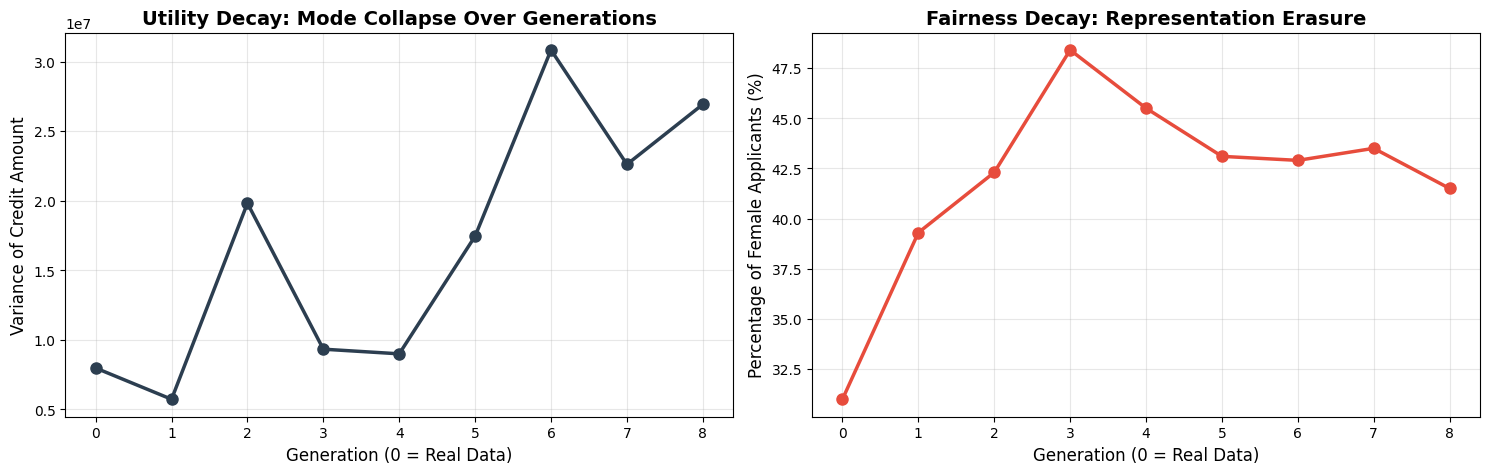

In [2]:

!pip install -q sdv pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import warnings
warnings.filterwarnings('ignore')

print("1. Fetching German Credit Data...")

german_data = fetch_openml('credit-g', version=1, as_frame=True, parser='auto')
df_real = german_data.frame


for col in df_real.select_dtypes(include=['category']).columns:
    df_real[col] = df_real[col].astype('object')


metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)


generations = [df_real]
current_data = df_real


variance_tracker = [df_real['credit_amount'].var()]
female_ratio_tracker = [(df_real['personal_status'].str.contains('female', case=False, na=False)).mean() * 100]

print("2. Starting 8-Generation CTGAN Loop...")
for i in range(1, 9):
    print(f"   Training Generation {i}...")

    synthesizer = CTGANSynthesizer(metadata, epochs=10, verbose=False)
    synthesizer.fit(current_data)
    synth_data = synthesizer.sample(num_rows=len(df_real))

    generations.append(synth_data)
    current_data = synth_data


    variance_tracker.append(synth_data['credit_amount'].var())
    female_ratio_tracker.append((synth_data['personal_status'].str.contains('female', case=False, na=False)).mean() * 100)

print("\n3. Testing for Reverse Engineering (Exact Matches in Gen 1)...")

real_tuples = set(tuple(x) for x in df_real.to_numpy())
synth_tuples = set(tuple(x) for x in generations[1].to_numpy())
exact_matches = real_tuples.intersection(synth_tuples)
print(f"   Exact Replicated Rows (Privacy Leakage): {len(exact_matches)}")

print("\n4. Generating Presentation Plots...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(range(9), variance_tracker, marker='o', color='#2c3e50', linewidth=2.5, markersize=8)
ax1.set_title('Utility Decay: Mode Collapse Over Generations', fontsize=14, fontweight='bold')
ax1.set_xlabel('Generation (0 = Real Data)', fontsize=12)
ax1.set_ylabel('Variance of Credit Amount', fontsize=12)
ax1.grid(True, alpha=0.3)


ax2.plot(range(9), female_ratio_tracker, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
ax2.set_title('Fairness Decay: Representation Erasure', fontsize=14, fontweight='bold')
ax2.set_xlabel('Generation (0 = Real Data)', fontsize=12)
ax2.set_ylabel('Percentage of Female Applicants (%)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


1. Calculating Downstream ML Accuracy (TSTR) across generations...
2. Generating Advanced Presentation Plots...


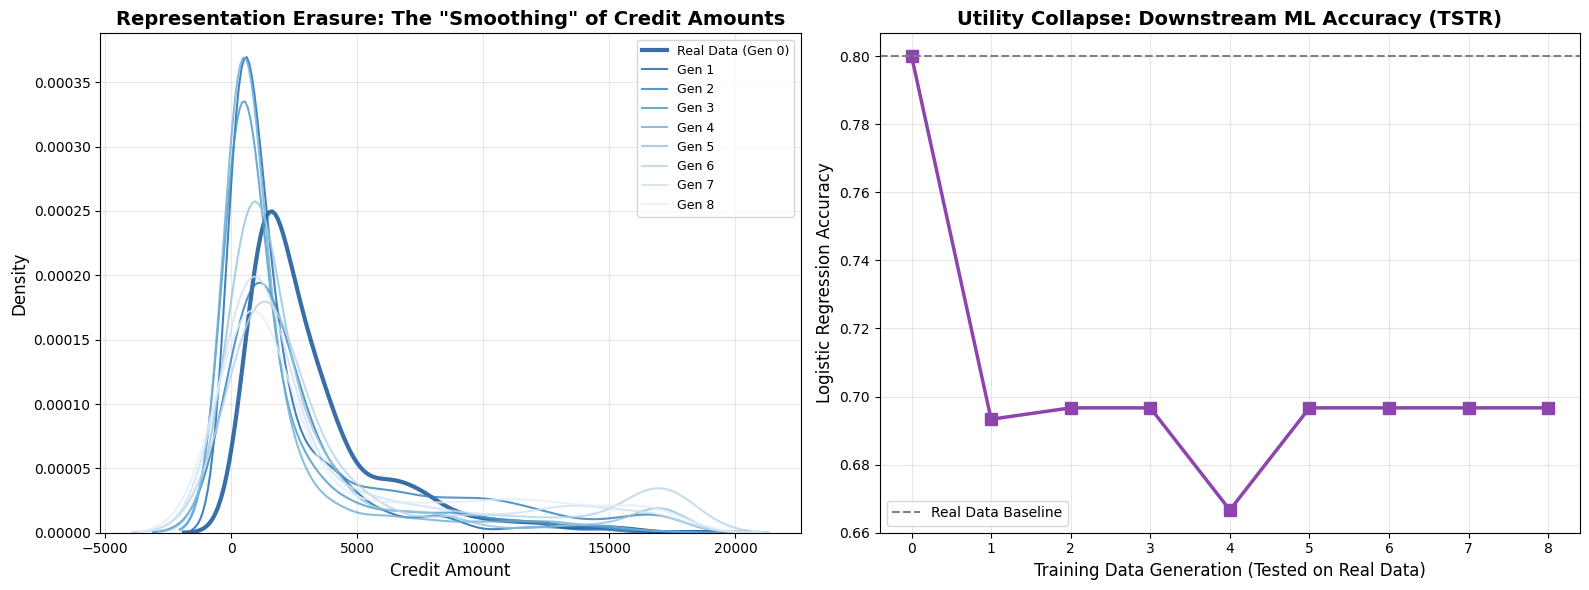

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("1. Calculating Downstream ML Accuracy (TSTR) across generations...")

X_real = df_real.drop('class', axis=1)
y_real = df_real['class']


X_real_encoded = pd.get_dummies(X_real, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_real_encoded, y_real, test_size=0.3, random_state=42)

accuracy_scores = []

for i, gen_df in enumerate(generations):

    X_synth = gen_df.drop('class', axis=1)
    y_synth = gen_df['class']


    X_synth_encoded = pd.get_dummies(X_synth, drop_first=True)
    X_synth_encoded = X_synth_encoded.reindex(columns=X_train.columns, fill_value=0)


    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_synth_encoded, y_synth)
    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    accuracy_scores.append(acc)

print("2. Generating Advanced Presentation Plots...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


colors = sns.color_palette("Blues_r", n_colors=9)

for i, gen_df in enumerate(generations):
    label = 'Real Data (Gen 0)' if i == 0 else f'Gen {i}'
    linewidth = 3 if i == 0 else 1.5
    sns.kdeplot(data=gen_df, x='credit_amount', ax=ax1, color=colors[i],
                label=label, linewidth=linewidth, alpha=0.8)

ax1.set_title('Representation Erasure: The "Smoothing" of Credit Amounts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Credit Amount', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)


ax2.plot(range(9), accuracy_scores, marker='s', color='#8e44ad', linewidth=2.5, markersize=8)
ax2.axhline(y=accuracy_scores[0], color='gray', linestyle='--', label='Real Data Baseline')
ax2.set_title('Utility Collapse: Downstream ML Accuracy (TSTR)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Training Data Generation (Tested on Real Data)', fontsize=12)
ax2.set_ylabel('Logistic Regression Accuracy', fontsize=12)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()